# Notebook 4 — Build Baskets (Apriori Preparation)

**Goal:** Build transaction baskets for Apriori with a proper chronological split.

This notebook:
- Builds baskets by `order_id` (each order = one basket)
- Creates a proper split per user:
  - `train_rules` = earlier PRIOR orders
  - `validation` = last PRIOR order
  - `test` = TRAIN order (final order)
- Attaches customer segments (`rare`, `frequent`, `heavy`) from Notebook 3
- Saves clean basket tables to the `outputs` folder
- Adds a generator function and a sparse representation (memory-friendly)

In [11]:
import os
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder

In [12]:
def load_instacart_tables():
    """
    Load Instacart tables from CSV files.

    Returns
    -------
    dict
        Main Instacart tables.
    """
    tables = {
        "orders": pd.read_csv("../data/orders.csv"),
        "order_products__prior": pd.read_csv("../data/order_products__prior.csv"),
        "order_products__train": pd.read_csv("../data/order_products__train.csv"),
        "products": pd.read_csv("../data/products.csv"),
        "aisles": pd.read_csv("../data/aisles.csv"),
        "departments": pd.read_csv("../data/departments.csv"),
    }
    return tables


def load_segmented_users(file_name="segmented_users.csv"):
    """
    Load the segmentation output from Notebook 3.

    Parameters
    ----------
    file_name : str
        CSV file containing user segmentation.

    Returns
    -------
    DataFrame
        Segmented users table.
    """
    return pd.read_csv(file_name)


def enrich_products(products, aisles, departments):
    """
    Merge products with aisles and departments.

    Returns
    -------
    DataFrame
        Products with aisle and department names.
    """
    df = products.merge(aisles, on="aisle_id", how="left")
    df = df.merge(departments, on="department_id", how="left")
    return df


def build_order_split(orders, op_prior, op_train):
    """
    Build a chronological split per user.

    Split logic
    -----------
    - train_rules: earlier PRIOR orders
    - validation: last PRIOR order
    - test: TRAIN order (final order)

    Returns
    -------
    DataFrame
        One row per order_id with user_id and split label.
    """
    prior_order_ids = set(op_prior["order_id"].unique())
    train_order_ids = set(op_train["order_id"].unique())

    # PRIOR orders only, sorted by user timeline
    prior_orders = orders[orders["order_id"].isin(prior_order_ids)].copy()
    prior_orders = prior_orders.sort_values(["user_id", "order_number"])

    # Last prior order per user -> validation
    val_orders = prior_orders.groupby("user_id").tail(1)[["user_id", "order_id", "order_number"]].copy()
    val_orders["split"] = "validation"

    # Remaining prior orders -> train_rules
    train_rules_orders = prior_orders.merge(
        val_orders[["order_id"]],
        on="order_id",
        how="left",
        indicator=True
    )
    train_rules_orders = train_rules_orders[train_rules_orders["_merge"] == "left_only"].copy()
    train_rules_orders = train_rules_orders[["user_id", "order_id", "order_number"]]
    train_rules_orders["split"] = "train_rules"

    # TRAIN orders -> test final
    test_orders = orders[orders["order_id"].isin(train_order_ids)][["user_id", "order_id", "order_number"]].copy()
    test_orders["split"] = "test"

    split_df = pd.concat([train_rules_orders, val_orders, test_orders], ignore_index=True)
    return split_df


def check_split_summary(split_df):
    """
    Summarize the number of orders per split.

    Returns
    -------
    DataFrame
        Counts and percentages by split.
    """
    counts = split_df["split"].value_counts().reset_index()
    counts.columns = ["split", "n_orders"]
    counts["pct_orders"] = counts["n_orders"] / counts["n_orders"].sum()
    return counts


def check_split_per_user(split_df):
    """
    Check how many users have each split type.

    Returns
    -------
    DataFrame
        User coverage by split.
    """
    user_split = split_df.groupby(["user_id", "split"]).size().reset_index(name="n")
    summary = user_split.groupby("split")["user_id"].nunique().reset_index(name="n_users")
    summary["pct_users"] = summary["n_users"] / summary["n_users"].sum()
    return summary


def build_baskets_from_order_products(order_products, split_df):
    """
    Build baskets by order_id and attach split info.

    Parameters
    ----------
    order_products : DataFrame
        Combined prior + train order-product lines.
    split_df : DataFrame
        Output of build_order_split().

    Returns
    -------
    DataFrame
        Basket table with:
        - order_id
        - user_id
        - order_number
        - split
        - items (list of product_id)
    """
    baskets = order_products.groupby("order_id")["product_id"].apply(list).reset_index()
    baskets.columns = ["order_id", "items"]

    baskets = baskets.merge(split_df, on="order_id", how="inner")
    baskets = baskets[["order_id", "user_id", "order_number", "split", "items"]]

    return baskets


def attach_segments_to_baskets(baskets, segmented_users):
    """
    Attach customer segment to each basket.

    Returns
    -------
    DataFrame
        Basket table with segment column.
    """
    out = baskets.merge(segmented_users[["user_id", "segment"]], on="user_id", how="left")
    return out


def add_basket_metadata(baskets, products_enriched):
    """
    Add useful basket metadata:
    - basket_size
    - n_departments
    - n_aisles

    Returns
    -------
    DataFrame
        Basket table with metadata columns.
    """
    # Basket size
    out = baskets.copy()
    out["basket_size"] = out["items"].apply(len)

    # Build long format to count distinct departments/aisles per basket
    exploded = out[["order_id", "items"]].explode("items").rename(columns={"items": "product_id"})
    exploded = exploded.merge(
        products_enriched[["product_id", "department", "aisle"]],
        on="product_id",
        how="left"
    )

    dep_counts = exploded.groupby("order_id")["department"].nunique().reset_index(name="n_departments")
    aisle_counts = exploded.groupby("order_id")["aisle"].nunique().reset_index(name="n_aisles")

    out = out.merge(dep_counts, on="order_id", how="left")
    out = out.merge(aisle_counts, on="order_id", how="left")

    return out


def split_baskets(baskets):
    """
    Split basket table into train_rules / validation / test.

    Returns
    -------
    tuple
        (train_rules_baskets, validation_baskets, test_baskets)
    """
    train_rules_baskets = baskets[baskets["split"] == "train_rules"].copy()
    validation_baskets = baskets[baskets["split"] == "validation"].copy()
    test_baskets = baskets[baskets["split"] == "test"].copy()
    return train_rules_baskets, validation_baskets, test_baskets


def basket_summary_by_split(baskets):
    """
    Summarize basket statistics by split.

    Returns
    -------
    DataFrame
        Mean/median basket size and counts by split.
    """
    summary = baskets.groupby("split").agg(
        n_baskets=("order_id", "nunique"),
        n_users=("user_id", "nunique"),
        avg_basket_size=("basket_size", "mean"),
        median_basket_size=("basket_size", "median"),
        avg_n_departments=("n_departments", "mean"),
        avg_n_aisles=("n_aisles", "mean")
    ).reset_index()
    return summary


def basket_summary_by_segment_and_split(baskets):
    """
    Summarize basket statistics by segment and split.

    Returns
    -------
    DataFrame
        Basket stats by segment and split.
    """
    summary = baskets.groupby(["split", "segment"]).agg(
        n_baskets=("order_id", "nunique"),
        n_users=("user_id", "nunique"),
        avg_basket_size=("basket_size", "mean"),
        median_basket_size=("basket_size", "median")
    ).reset_index()
    return summary


def plot_basket_size_by_split(baskets):
    """
    Plot basket size distribution by split.
    """
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=baskets, x="split", y="basket_size", order=["train_rules", "validation", "test"])
    plt.title("Basket size by split")
    plt.xlabel("split")
    plt.ylabel("basket size")
    plt.show()


def plot_basket_size_by_segment(baskets):
    """
    Plot basket size distribution by segment and split.
    """
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=baskets, x="segment", y="basket_size", hue="split", order=["rare", "frequent", "heavy"])
    plt.title("Basket size by segment and split")
    plt.xlabel("segment")
    plt.ylabel("basket size")
    plt.show()


def transaction_generator(baskets_df):
    """
    Yield transactions one by one (generator).

    Parameters
    ----------
    baskets_df : DataFrame
        Basket table with an 'items' column.

    Yields
    ------
    list
        One basket (list of product_id).
    """
    for items in baskets_df["items"]:
        yield items


def build_sparse_matrix_from_baskets(baskets_df):
    """
    Build a sparse one-hot matrix for Apriori preparation.

    Parameters
    ----------
    baskets_df : DataFrame
        Basket table with an 'items' column.

    Returns
    -------
    tuple
        (sparse_matrix, product_columns)
    """
    te = TransactionEncoder()
    X_sparse = te.fit(baskets_df["items"]).transform(baskets_df["items"], sparse=True)
    product_columns = list(te.columns_)
    return X_sparse, product_columns


def save_baskets_outputs(all_baskets, train_rules_baskets, validation_baskets, test_baskets):
    """
    Save basket outputs to the outputs folder.

    Saved files
    -----------
    - outputs/baskets_all.csv
    - outputs/baskets_train_rules.csv
    - outputs/baskets_validation.csv
    - outputs/baskets_test.csv
    """
    os.makedirs("outputs", exist_ok=True)

    all_baskets.to_csv("../outputs/baskets_all.csv", index=False)
    train_rules_baskets.to_csv("../outputs/baskets_train_rules.csv", index=False)
    validation_baskets.to_csv("../outputs/baskets_validation.csv", index=False)
    test_baskets.to_csv("../outputs/baskets_test.csv", index=False)


def save_split_output(split_df):
    """
    Save split table to outputs folder.
    """
    os.makedirs("outputs", exist_ok=True)
    split_df.to_csv("outputs/order_split.csv", index=False)

In [13]:
# 1) Load data
tables = load_instacart_tables()

orders = tables["orders"]
op_prior = tables["order_products__prior"]
op_train = tables["order_products__train"]
products = tables["products"]
aisles = tables["aisles"]
departments = tables["departments"]

products_enriched = enrich_products(products, aisles, departments)

# Segmentation output from Notebook 3
segmented_users = load_segmented_users("../outputs/segmented_users.csv")

In [14]:
# 2) Build chronological split (per user)
split_df = build_order_split(orders, op_prior, op_train)

display(check_split_summary(split_df))
display(check_split_per_user(split_df))

# Quick check: split order by timeline (train_rules < validation < test)
# We compare average order_number by split to confirm chronology
timeline_check = split_df.groupby("split")["order_number"].agg(["count", "mean", "median", "min", "max"]).reset_index()
display(timeline_check)

# Save split table
save_split_output(split_df)


,split,n_orders,pct_orders
0,train_rules,3008665,0.899160
1,validation,206209,0.061627
2,test,131209,0.039213


,split,n_users,pct_users
0,test,131209,0.241359
1,train_rules,206209,0.379321
2,validation,206209,0.379321


,split,count,mean,median,min,max
0,test,131209,16.603937,10.0,4,100
1,train_rules,3008665,17.300775,11.0,1,98
2,validation,206209,15.590367,9.0,3,99


In [15]:
# 3) Combine PRIOR + TRAIN order-product lines, then build baskets by order_id
op_all = pd.concat([op_prior, op_train], ignore_index=True)

baskets = build_baskets_from_order_products(op_all, split_df)
baskets = attach_segments_to_baskets(baskets, segmented_users)
baskets = add_basket_metadata(baskets, products_enriched)

display(baskets.head())

,order_id,user_id,order_number,split,items,segment,basket_size,n_departments,n_aisles
0,1,112108,4,test,"[49302, 11109, 10246, 49683, 43633, 13176, 472...",rare,8,3,6
1,2,202279,3,train_rules,"[33120, 28985, 9327, 45918, 30035, 17794, 4014...",frequent,9,3,8
2,3,205970,16,train_rules,"[33754, 24838, 17704, 21903, 17668, 46667, 174...",heavy,8,4,6
3,4,178520,36,train_rules,"[46842, 26434, 39758, 27761, 10054, 21351, 225...",heavy,13,5,9
4,5,156122,42,train_rules,"[13176, 15005, 47329, 27966, 23909, 48370, 132...",heavy,26,11,19


In [16]:
# 4) Split basket tables
baskets_train_rules, baskets_validation, baskets_test = split_baskets(baskets)

display(basket_summary_by_split(baskets))
display(basket_summary_by_segment_and_split(baskets))

,split,n_baskets,n_users,avg_basket_size,median_basket_size,avg_n_departments,avg_n_aisles
0,test,131209,131209,10.552759,9.0,4.880694,7.551075
1,train_rules,3008665,206209,10.069151,8.0,4.728509,7.245589
2,validation,206209,206209,10.376792,9.0,4.847979,7.462827


,split,segment,n_baskets,n_users,avg_basket_size,median_basket_size
0,test,frequent,43291,43291,10.928276,9.0
1,test,heavy,43578,43578,13.890931,12.0
2,test,rare,44340,44340,6.905323,6.0
3,train_rules,frequent,652465,68217,8.025621,7.0
4,train_rules,heavy,2042628,68392,11.503480,10.0
5,train_rules,rare,313572,69600,4.977909,4.0
6,validation,frequent,68217,68217,11.047627,10.0
7,validation,heavy,68392,68392,13.894330,12.0
8,validation,rare,69600,69600,6.262802,5.0


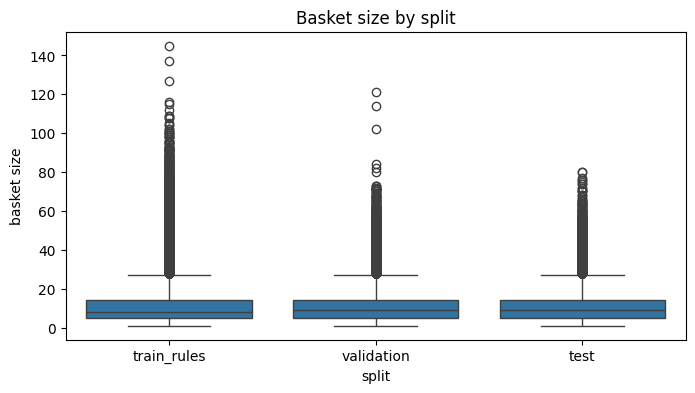

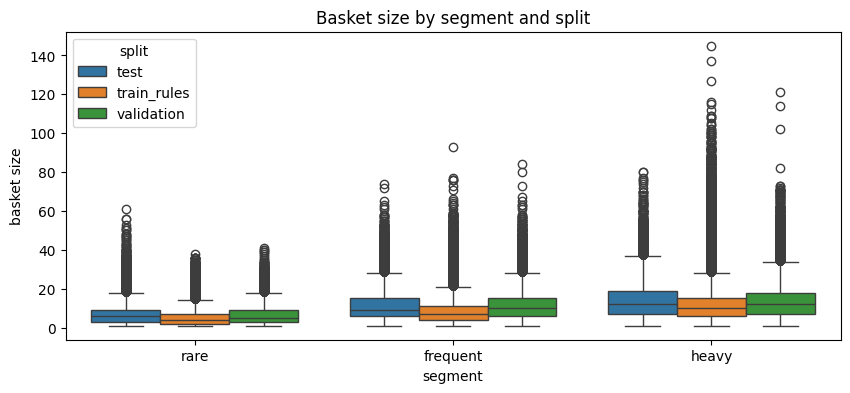

In [17]:
# 5) Plot basket distributions (sanity checks)
plot_basket_size_by_split(baskets)
plot_basket_size_by_segment(baskets)

In [18]:
# 6) Generator example (memory-friendly)
# We only display a few generated baskets to check the function
gen = transaction_generator(baskets_train_rules.head(3))
sample_generated = list(gen)

display(pd.DataFrame({
    "sample_generated_basket": sample_generated
}))

,sample_generated_basket
0,"[33120, 28985, 9327, 45918, 30035, 17794, 4014..."
1,"[33754, 24838, 17704, 21903, 17668, 46667, 174..."
2,"[46842, 26434, 39758, 27761, 10054, 21351, 225..."


In [19]:
# 7) Sparse representation for Apriori (train_rules only)
# Apriori train on train_rules baskets
X_sparse_train, train_product_columns = build_sparse_matrix_from_baskets(baskets_train_rules)

sparse_info = pd.DataFrame([{
    "split": "train_rules",
    "n_baskets": X_sparse_train.shape[0],
    "n_products_columns": X_sparse_train.shape[1],
    "nnz_non_zero_values": X_sparse_train.nnz
}])

display(sparse_info)

,split,n_baskets,n_products_columns,nnz_non_zero_values
0,train_rules,3008665,49652,30294701


In [20]:
# 8) Save outputs for next notebooks (rules mining and evaluation)
save_baskets_outputs(
    all_baskets=baskets,
    train_rules_baskets=baskets_train_rules,
    validation_baskets=baskets_validation,
    test_baskets=baskets_test
)

In [21]:
# 9) previews from outputs-ready tables
display(baskets_train_rules.head())
display(baskets_validation.head())
display(baskets_test.head())

,order_id,user_id,order_number,split,items,segment,basket_size,n_departments,n_aisles
1,2,202279,3,train_rules,"[33120, 28985, 9327, 45918, 30035, 17794, 4014...",frequent,9,3,8
2,3,205970,16,train_rules,"[33754, 24838, 17704, 21903, 17668, 46667, 174...",heavy,8,4,6
3,4,178520,36,train_rules,"[46842, 26434, 39758, 27761, 10054, 21351, 225...",heavy,13,5,9
4,5,156122,42,train_rules,"[13176, 15005, 47329, 27966, 23909, 48370, 132...",heavy,26,11,19
5,6,22352,4,train_rules,"[40462, 15873, 41897]",frequent,3,2,3


,order_id,user_id,order_number,split,items,segment,basket_size,n_departments,n_aisles
23,25,59897,19,validation,"[9755, 31487, 37510, 14576, 22105, 1934, 6383,...",heavy,14,6,11
37,40,382,29,validation,"[10070, 42450, 33198, 34866]",heavy,4,3,3
40,43,39630,14,validation,"[20915, 21949, 8817, 37867, 12850, 21553, 34005]",frequent,7,5,6
48,51,160959,6,validation,"[30274, 3594, 14994, 45433, 44514, 32624, 604,...",frequent,9,6,7
80,83,41155,7,validation,"[13176, 1087, 35503, 4945, 40587, 11574, 37935...",frequent,14,8,12


,order_id,user_id,order_number,split,items,segment,basket_size,n_departments,n_aisles
0,1,112108,4,test,"[49302, 11109, 10246, 49683, 43633, 13176, 472...",rare,8,3,6
33,36,79431,23,test,"[39612, 19660, 49235, 43086, 46620, 34497, 486...",heavy,8,4,7
35,38,42756,6,test,"[11913, 18159, 4461, 21616, 23622, 32433, 2884...",rare,9,4,6
93,96,17227,7,test,"[20574, 30391, 40706, 25610, 27966, 24489, 39275]",rare,7,3,4
95,98,56463,41,test,"[8859, 19731, 43654, 13176, 4357, 37664, 34065...",heavy,49,12,35
